# Old Book Illustration Generator

Fine-tune Stable Diffusion v1.4 on vintage book illustrations and compare the **same prompt before vs. after** fine-tuning.

## 0. Setup

In [ ]:
import logging
import os
from pathlib import Path

from datasets import load_dataset
from diffusers import (
    AutoencoderKL,
    DDPMScheduler,
    StableDiffusionPipeline,
    UNet2DConditionModel,
)
from torch.utils.data import DataLoader, Dataset
from transformers import CLIPTextModel, CLIPTokenizer
from torchvision import transforms
from accelerate import Accelerator
from tqdm import tqdm
from dotenv import load_dotenv

import torch

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
)
logger = logging.getLogger(__name__)

load_dotenv()

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

# Config (values from .env, inlined for Colab where there's no local .env file):
base_model_name = "CompVis/stable-diffusion-v1-4"
dataset_name = "gigant/oldbookillustrations"
dataset_columns = "1600px,info_alt".split(",")
max_train_samples = 20
batch_size = 1
final_model_name = "vintage-bookshop-practice-rss"
resolution = 64
crop_type = "resize_crop"  # center by default
learning_rate = 1e-5
training_epochs = 2


hggf_username = os.getenv("HGGF_USERNAME", "")
hggf_token = os.getenv("HGGF_TOKEN", "")


torch.set_num_threads(4)

## 1. Base model behavior (before fine-tuning)

Define the `prompt` once here and reuse it unchanged in section 5 for a fair before/after comparison.

In [3]:
def _geometry_transforms(image, normalization_list, resolution=512, crop="center"):
    """Crop, resize, tensorize and normalize a PIL image."""
    if crop == "resize_crop":
        logger.info("Executing _geometry_transforms with resize crop")
        result = transforms.Compose([
            transforms.Resize(resolution),
            transforms.CenterCrop(resolution),
            transforms.ToTensor(),
            transforms.Normalize(normalization_list, normalization_list),
        ])(image)
        logger.info("Finished _geometry_transforms, final image size: %s", tuple(result.shape))
        return result

    # Center crop
    logger.info("Executing _geometry_transforms with center crop")
    min_side = min(image.size)
    result = transforms.Compose([
        transforms.CenterCrop(min_side),
        transforms.Resize((resolution, resolution)),
        transforms.ToTensor(),
        transforms.Normalize(normalization_list, normalization_list),
    ])(image)
    logger.info("Finished _geometry_transforms, final image size: %s", tuple(result.shape))
    return result


def to_rgb_image_tensors(sample_image, column_name: str, resolution=1600, crop="center"):
    """Convert a dataset sample's image to a normalized RGB tensor."""
    logger.info("Executing to_rgb_image_tensors")
    image = sample_image[column_name].convert("RGB")
    result = _geometry_transforms(image, [0.5, 0.5, 0.5], resolution, crop)
    logger.info("Finished to_rgb_image_tensors")
    return result

def _load_model(device="cpu"):
    logger.info("Executing _load_model")
    pipeline = StableDiffusionPipeline.from_pretrained(base_model_name).to(device)
    logger.info("Finished _load_model")
    return pipeline


def retrieve_model(device="cpu"):
    """Return the base Stable Diffusion pipeline, using a local cache when available."""
    logger.info("Executing retrieve_model")

    logger.info("Local base model not found, downloading from Hub")
    pipeline = _load_model(device)
    logger.info("Finished retrieve_model")
    return pipeline

In [14]:
pipeline = retrieve_model(device)

prompt = "a vintage book illustration of a sailing ship on a stormy sea"
image = pipeline(prompt).images[0]
image

2026-06-23 01:04:20,067 | INFO | __main__ | Executing retrieve_model
2026-06-23 01:04:20,070 | INFO | __main__ | Local base model not found, downloading from Hub
2026-06-23 01:04:20,072 | INFO | __main__ | Executing _load_model
2026-06-23 01:04:20,250 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/models/CompVis/stable-diffusion-v1-4 "HTTP/1.1 200 OK"
2026-06-23 01:04:20,405 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/CompVis/stable-diffusion-v1-4/resolve/main/model_index.json "HTTP/1.1 307 Temporary Redirect"
2026-06-23 01:04:20,425 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/CompVis/stable-diffusion-v1-4/133a221b8aa7292a167afc5127cb63fb5005638b/model_index.json "HTTP/1.1 200 OK"
Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

: 

## 2. Load model components

Free the base pipeline's UNet from the device first (it gets replaced in section 5 anyway) to make room before loading the training components.

In [5]:
def retrieve_model_parts(device="cpu"):
    """Load the individual Stable Diffusion components needed for UNet fine-tuning."""
    logger.info("Executing retrieve_model_parts")

    logger.info("Local base model not found, loading parts from Hub")
    model_source = base_model_name

    # Tokenizador:
    tokenizer = CLIPTokenizer.from_pretrained(model_source, subfolder="tokenizer")
    # Scheduler:
    noise_scheduler = DDPMScheduler.from_pretrained(model_source, subfolder="scheduler")
    # Text Encoder (CLIP):
    text_encoder = CLIPTextModel.from_pretrained(
        model_source, subfolder="text_encoder").to(device)
    # VAE: Autoencoder:
    vae = AutoencoderKL.from_pretrained(model_source, subfolder="vae").to(device)
    # La UNet:
    unet = UNet2DConditionModel.from_pretrained(model_source, subfolder="unet").to(device)
    # Congelamos los pesos del VAE y del Text Encoder, ya que solo queremos finetunear la UNet:
    vae.eval()
    text_encoder.eval()

    for param in vae.parameters():
        param.requires_grad = False
    for param in text_encoder.parameters():
        param.requires_grad = False

    logger.info("Finished retrieve_model_parts")
    return tokenizer, noise_scheduler, text_encoder, vae, unet

In [6]:
# Free the base UNet from the device before loading the training components.
# We keep `pipeline` (reused in section 5) but drop its heavy UNet, which is
# replaced by the fine-tuned one later.
# del pipeline
if device == "cuda":
    torch.cuda.empty_cache()

tokenizer, noise_scheduler, text_encoder, vae, unet = retrieve_model_parts(device)

2026-06-22 23:25:17,087 | INFO | __main__ | Executing retrieve_model_parts
2026-06-22 23:25:17,090 | INFO | __main__ | Local base model not found, loading parts from Hub
2026-06-22 23:25:17,942 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/CompVis/stable-diffusion-v1-4/resolve/main/tokenizer/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-22 23:25:17,959 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/CompVis/stable-diffusion-v1-4/133a221b8aa7292a167afc5127cb63fb5005638b/tokenizer%2Ftokenizer_config.json "HTTP/1.1 200 OK"
2026-06-22 23:25:18,103 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/models/CompVis/stable-diffusion-v1-4/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-06-22 23:25:18,242 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/models/CompVis/stable-diffusion-v1-4/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
c:\Users\asus\M

## 3. Training data

In [ ]:
class Text2ImageDataset(Dataset):
    """Wraps a Hugging Face dataset of (image, text) pairs for text-to-image fine-tuning."""

    def __init__(self, dataset, tokenizer):
        self.dataset = dataset
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        example = self.dataset[idx]
        image = to_rgb_image_tensors(
            sample_image=example,
            column_name=dataset_columns[0],
            resolution=resolution,
            crop=crop_type)
        token = self.tokenizer(
            example[dataset_columns[1]],
            padding="max_length",
            truncation=True,
            max_length=self.tokenizer.model_max_length,
            return_tensors="pt",
        )
        item = {
            "pixel_values": image,
            "input_ids": token.input_ids.squeeze(0),
            "attention_mask": token.attention_mask.squeeze(0),
        }
        return item


def _load_dataset(split_dataset="train"):
    logger.info("Executing _load_dataset")
    dataset = load_dataset(dataset_name, split=split_dataset).select_columns(dataset_columns)

    selected = dataset.select(range(max_train_samples))
    logger.info("Finished _load_dataset")
    return selected


def get_traindata_loader(tokenizer):
    """Build the training `DataLoader` over the vintage-book illustrations dataset."""
    logger.info("Executing get_traindata_loader")
    filtered_dataset = _load_dataset()

    train_dataset = Text2ImageDataset(filtered_dataset, tokenizer)
    loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    logger.info("Finished get_traindata_loader")

    return loader

In [8]:
traindata_loader = get_traindata_loader(tokenizer)

2026-06-22 23:25:20,233 | INFO | __main__ | Executing get_traindata_loader
2026-06-22 23:25:20,236 | INFO | __main__ | Executing _load_dataset
2026-06-22 23:25:20,368 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/gigant/oldbookillustrations/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-06-22 23:25:20,382 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/gigant/oldbookillustrations/40cc352405da6da57bd64ba785bd6a38ef3a4871/README.md "HTTP/1.1 200 OK"
2026-06-22 23:25:20,515 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/gigant/oldbookillustrations/resolve/40cc352405da6da57bd64ba785bd6a38ef3a4871/oldbookillustrations.py "HTTP/1.1 404 Not Found"
2026-06-22 23:25:20,819 | INFO | httpx | HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/gigant/oldbookillustrations/gigant/oldbookillustrations.py "HTTP/1.1 404 Not Found"
2026-06-22 23:25:20,965 | INFO | httpx | HTT

## 4. Fine-tuning

In [ ]:
def _prepare_training(unet, traindata_loader):
    logger.info("Executing _prepare_training")
    optimizer = torch.optim.AdamW(unet.parameters(), lr=learning_rate)

    # Acelerador:
    accelerator = Accelerator()
    unet, optimizer, __ = accelerator.prepare(unet, optimizer, traindata_loader)
    logger.info("Accelerator device: %s", accelerator.device)

    logger.info("Finished _prepare_training")
    return accelerator, unet, optimizer


def start_fine_tunning(traindata_loader, model_parts: tuple, device: str = "cpu"):
    """Fine-tune the Stable Diffusion UNet on the given training data."""
    logger.info("Executing start_fine_tunning")
    noise_scheduler, text_encoder, vae, unet = model_parts

    accelerator, unet, optimizer = _prepare_training(unet, traindata_loader)

    for epoch in range(training_epochs):
        logger.info("Epoch %d executing", epoch)
        progress_bar = tqdm(traindata_loader, desc=f"Epoch {epoch}")

        for batch in progress_bar:
            # Se pasan los pixeles al espacio latente con el encoder del VAE:
            with torch.no_grad():
                pixel_values = batch["pixel_values"].to(accelerator.device)
                latents = vae.encode(pixel_values).latent_dist.sample()
                latents = latents * 0.18215

            # Proceso de difusion hacia delante:
            # 1. Creamos ruido aleatorio
            noise = torch.randn_like(latents)
            # 2. Cogemos un timestep aleatorio:
            timesteps = torch.randint(
                0,
                noise_scheduler.config.num_train_timesteps,
                (latents.shape[0],),
                device=latents.device,
            ).long()
            # 3. Añadimos ruido al vector del espacio latente:
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

            # Codificamos el texto:
            input_ids = batch["input_ids"].to(accelerator.device)
            encoder_hidden_states = text_encoder(input_ids)[0]

            # Con el vector con ruido, el timestep, y el vector de texto, hacemos la prediccion de ruido:
            noise_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample

            # Calculamos el error y actualizamos los parametros:
            loss = torch.nn.functional.mse_loss(noise_pred, noise)
            accelerator.backward(loss)
            optimizer.step()
            optimizer.zero_grad()

            progress_bar.set_postfix(loss=loss.item())

    unwrapped_unet = accelerator.unwrap_model(unet)
    logger.info("Finished start_fine_tunning")
    return unwrapped_unet

In [10]:
fine_tuned_unet = start_fine_tunning(
    traindata_loader,
    (noise_scheduler, text_encoder, vae, unet),
    device,
)

2026-06-22 23:25:24,762 | INFO | __main__ | Executing start_fine_tunning
2026-06-22 23:25:24,762 | INFO | __main__ | Executing _prepare_training
2026-06-22 23:25:24,813 | INFO | __main__ | Accelerator device: cpu
2026-06-22 23:25:24,813 | INFO | __main__ | Finished _prepare_training
2026-06-22 23:25:24,816 | INFO | __main__ | Epoch 0 executing
Epoch 0:   0%|          | 0/20 [00:00<?, ?it/s]2026-06-22 23:25:24,882 | INFO | __main__ | Executing to_rgb_image_tensors
2026-06-22 23:25:24,885 | INFO | __main__ | Executing _geometry_transforms with resize crop
2026-06-22 23:25:24,906 | INFO | __main__ | Finished _geometry_transforms, final image size: (3, 64, 64)
2026-06-22 23:25:24,906 | INFO | __main__ | Finished to_rgb_image_tensors
Epoch 0:   5%|▌         | 1/20 [01:48<34:26, 108.78s/it, loss=0.175]2026-06-22 23:27:13,816 | INFO | __main__ | Executing to_rgb_image_tensors
2026-06-22 23:27:13,836 | INFO | __main__ | Executing _geometry_transforms with resize crop
2026-06-22 23:27:13,964 | 

## 5. Fine-tuned model behavior (after) — same prompt

Swap in the fine-tuned UNet and generate with the **same `prompt`** as section 1 to compare.

2026-06-23 00:50:46,446 | INFO | __main__ | Executing retrieve_model
2026-06-23 00:50:46,450 | INFO | __main__ | Local base model not found, downloading from Hub
2026-06-23 00:50:46,450 | INFO | __main__ | Executing _load_model
2026-06-23 00:50:47,546 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/models/CompVis/stable-diffusion-v1-4 "HTTP/1.1 200 OK"
2026-06-23 00:50:47,710 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/CompVis/stable-diffusion-v1-4/resolve/main/model_index.json "HTTP/1.1 307 Temporary Redirect"
2026-06-23 00:50:47,731 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/CompVis/stable-diffusion-v1-4/133a221b8aa7292a167afc5127cb63fb5005638b/model_index.json "HTTP/1.1 200 OK"
Loading pipeline components...: 100%|██████████| 7/7 [00:05<00:00,  1.36it/s]
2026-06-23 00:50:53,043 | INFO | __main__ | Finished _load_model
2026-06-23 00:50:53,043 | INFO | __main__ | Finished retrieve_model
2026-06-23 00:50:53,199 | INF

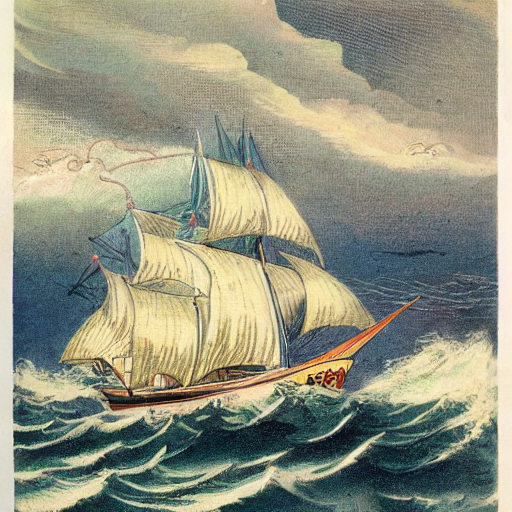

In [11]:
pipeline = retrieve_model(device)

pipeline.unet = fine_tuned_unet

pipeline = StableDiffusionPipeline.from_pretrained(
    base_model_name,
    unet=fine_tuned_unet,
    vae=vae,
    text_encoder=text_encoder,
    tokenizer=tokenizer,
).to(device)
image = pipeline(prompt).images[0]
image

## 6. (Optional) Upload fine-tuned model to the Hub

Run only to push the fine-tuned UNet to the Hub. Requires `HGGF_USERNAME` and `HGGF_TOKEN` in `.env`.

In [ ]:
def upload_model(unet):
    """Push a fine-tuned UNet to the Hugging Face Hub as a private repo."""
    logger.info("Executing upload_model")

    if hggf_username == '' or hggf_token == '':
        logger.error("HGGF_USERNAME or HGGF_TOKEN are empty")
        return

    unet.push_to_hub(
        repo_id=f"{hggf_username}/{final_model_name}-unet",
        commit_message="Fine tunned model upload",
        token=hggf_token
    )
    logger.info("Finished upload_model")

In [ ]:
upload_model(fine_tuned_unet)